This is the code for EDA, motivates the next step

In [1]:

# Setup 
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------- NeurIPS-ish matplotlib defaults ----------
plt.rcParams.update({
	"figure.dpi": 140,
	"savefig.dpi": 300,
	"font.size": 11,
	"axes.titlesize": 12,
	"axes.labelsize": 11,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10,
	"legend.fontsize": 10,
	"axes.spines.top": False,
	"axes.spines.right": False,
	"axes.grid": True,
	"grid.alpha": 0.18,
	"grid.linewidth": 0.8,
})

def savefig(path):
	plt.tight_layout()
	plt.savefig(path, bbox_inches="tight")


In [2]:
DEV_PATH = "../../data/raw/development.csv"
EVAL_PATH = "../../data/raw/evaluation.csv"
df_dev  = pd.read_csv(DEV_PATH)
df_eval = pd.read_csv(EVAL_PATH)

print("DEV:", df_dev.shape, "columns:", df_dev.columns.tolist())
print("EVAL:", df_eval.shape, "columns:", df_eval.columns.tolist())

df_dev.head(3)

DEV: (79997, 7) columns: ['Id', 'source', 'title', 'article', 'page_rank', 'timestamp', 'label']
EVAL: (20000, 6) columns: ['Id', 'source', 'title', 'article', 'page_rank', 'timestamp']


,Id,source,title,article,page_rank,timestamp,label
0,0,AllAfrica.com,OPEC Boosts Nigeria&#39;s Oil Revenue By .82m Bpd,THE Organisation of Petroleum Exporting Countr...,5,2004-09-16 22:39:53,5
1,1,Xinhua,Yearender: Mideast peace roadmap reaches dead-...,Looking back at the major events that took pla...,5,2004-12-17 19:01:14,0
2,2,Yahoo,Battleground Dispatches for Oct. 5 \\n (CQP...,CQPolitics.com - Here are today's Battleground...,5,2006-10-05 18:42:29,0


In [3]:

#  Basic health-check: missingness + simple distributions

def missingness_table(df):
	is_missing = df.isna()

	if "timestamp" in df.columns:
		ts = df["timestamp"].astype(str).str.strip()
		is_missing["timestamp"] |= ts.eq("0000-00-00 00:00:00")

	miss = is_missing.mean().sort_values(ascending=False)
	out = pd.DataFrame({
		"missing_frac": miss,
		"missing_count": (miss * len(df)).round().astype(int)
	})
	return out

miss_dev  = missingness_table(df_dev)
miss_eval = missingness_table(df_eval)

display(miss_dev)


,missing_frac,missing_count
timestamp,0.346888,27750
article,0.000013,1
title,0.000013,1
source,0.000000,0
Id,0.000000,0
page_rank,0.000000,0
label,0.000000,0


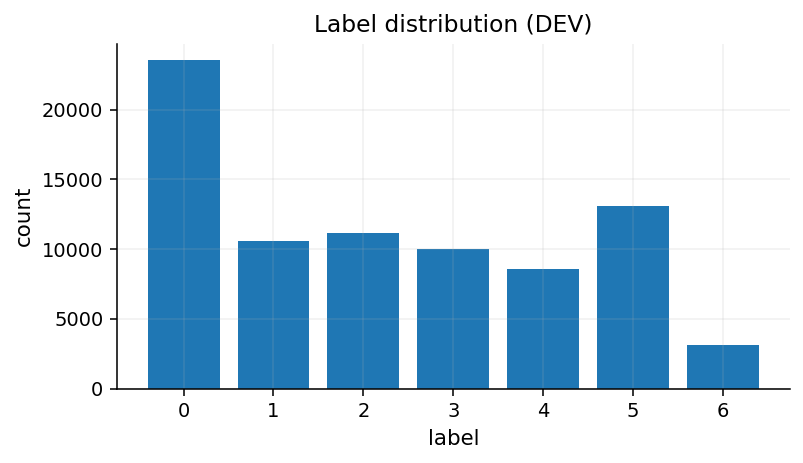

In [4]:
# Label distribution (DEV only)
label_col = "label" 
assert label_col in df_dev.columns, "Label column not found in DEV."

label_counts = df_dev[label_col].value_counts().sort_index()

plt.figure(figsize=(6.2,3.2))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Label distribution (DEV)")
plt.xlabel("label")
plt.ylabel("count")
plt.show()


In [5]:

#  Exact duplicates
def dup_stats(df, subset, name):
	dup_mask = df.duplicated(subset=subset, keep=False)
	n_dup_rows = int(dup_mask.sum())
	n_groups = df.loc[dup_mask].groupby(subset).size().shape[0] if n_dup_rows else 0
	print(f"[{name}] subset={subset}:")
	print(f"  duplicated rows: {n_dup_rows} / {len(df)}  ({n_dup_rows/len(df):.3%})")
	print(f"  duplicate groups: {n_groups}")
	return dup_mask

dup_article = dup_stats(df_dev, subset=["article"], name="DEV exact")
dup_title   = dup_stats(df_dev, subset=["title"],   name="DEV exact")
dup_pair    = dup_stats(df_dev, subset=["title","article"], name="DEV exact")


[DEV exact] subset=['article']:
  duplicated rows: 8426 / 79997  (10.533%)
  duplicate groups: 2823
[DEV exact] subset=['title']:
  duplicated rows: 7663 / 79997  (9.579%)
  duplicate groups: 3450
[DEV exact] subset=['title', 'article']:
  duplicated rows: 5499 / 79997  (6.874%)
  duplicate groups: 2545


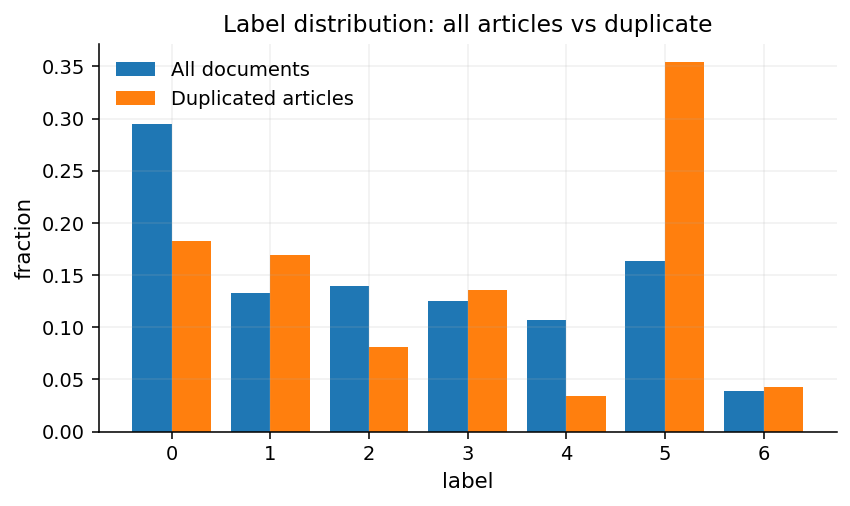

In [10]:

#Label distribution among duplicated articles



dup_df = df_dev.loc[dup_article, [label_col]]

label_counts_dup = dup_df[label_col].value_counts().sort_index()
label_counts_all = df_dev[label_col].value_counts().sort_index()


freq_dup = label_counts_dup / label_counts_dup.sum()
freq_all = label_counts_all / label_counts_all.sum()

x = np.arange(len(freq_all))

plt.figure(figsize=(6.8,3.6))
plt.bar(x - 0.2, freq_all.values, width=0.4, label="All documents")
plt.bar(x + 0.2, freq_dup.reindex(freq_all.index, fill_value=0).values,
		width=0.4, label="Duplicated articles")

plt.xticks(x, freq_all.index.astype(str))
plt.xlabel("label")
plt.ylabel("fraction")
plt.title("Label distribution: all articles vs duplicate")
plt.legend(frameon=False)
plt.show()


In [ ]:

# Exact duplicated articles with multiple labels


dup_label_groups = (
	df_dev.loc[dup_article]
	.groupby("article")[label_col]
	.nunique()
)

multi_label_articles = dup_label_groups[dup_label_groups > 1]

print("Duplicated articles with >1 label:", len(multi_label_articles))
print("Fraction over duplicated articles:",
	  len(multi_label_articles) / dup_label_groups.shape[0])


Duplicated articles with >1 label: 1614
Fraction over duplicated articles: 0.5717321997874601


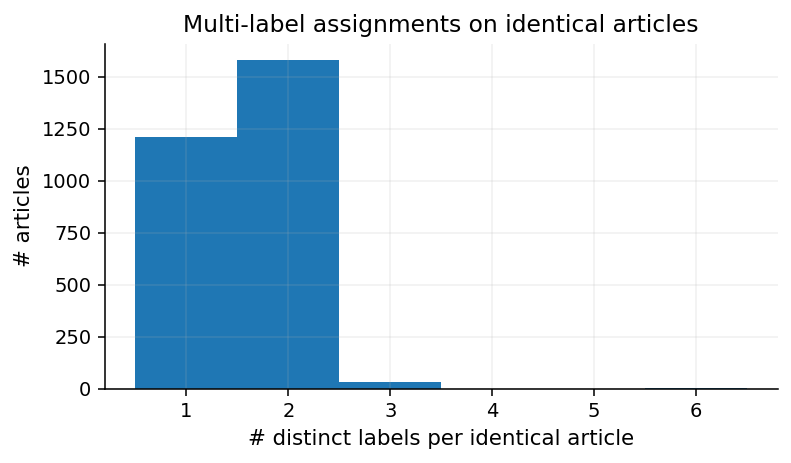

In [15]:
plt.figure(figsize=(6.2,3.2))
plt.hist(dup_label_groups.values, bins=np.arange(1, dup_label_groups.max()+2)-0.5)
plt.xticks(range(1, dup_label_groups.max()+1))
plt.xlabel("# distinct labels per identical article")
plt.ylabel("# articles")
plt.title("Multi-label assignments on identical articles")
plt.show()


We observed a non-negligible number of exact duplicate articles.
Importantly, a subset of these duplicates is associated with multiple labels, indicating that identical content can receive different class assignments depending on editorial context or source.
This supports the presence of label noise and motivates robust modeling choices.

In [9]:
# === Structural ambiguity: same (title, article) with different labels ===

# Group by exact (title, article) pair
pair_label_counts = (
	df_dev
	.groupby(["title", "article"])[label_col]
	.nunique()
)

# Select duplicated pairs
duplicated_pairs = pair_label_counts[pair_label_counts > 1]

# Counts
n_total_pairs = pair_label_counts.shape[0]
n_duplicated_pairs = duplicated_pairs.shape[0]

# Percentages
perc_duplicated_pairs = n_duplicated_pairs / n_total_pairs

print(f"Total unique (title, article) pairs: {n_total_pairs}")
print(f"Pairs with multiple labels: {n_duplicated_pairs}")
print(f"Percentage: {perc_duplicated_pairs:.4%}")


Total unique (title, article) pairs: 77041
Pairs with multiple labels: 1516
Percentage: 1.9678%


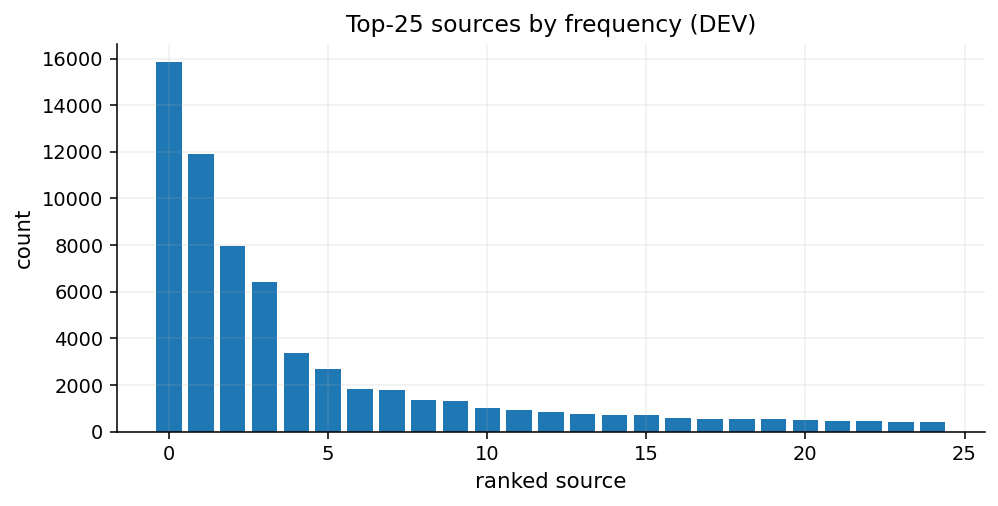

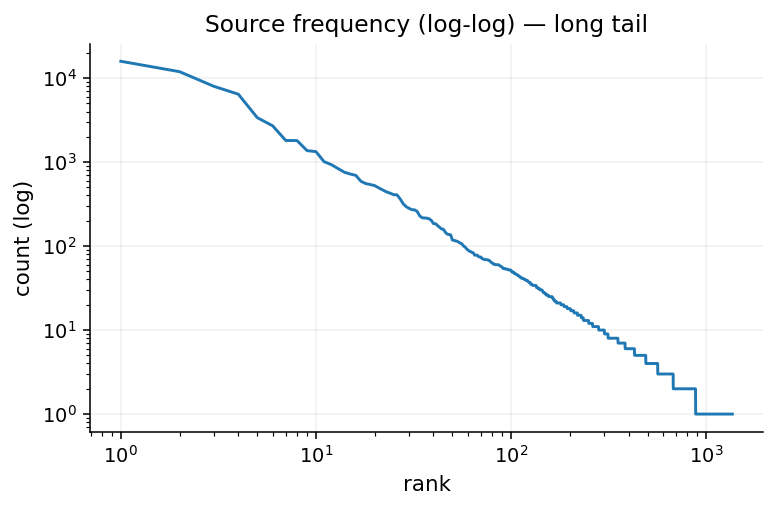

In [ ]:

#Source distribution

src_counts = df_dev["source"].value_counts()
topk = 25

plt.figure(figsize=(8.0,3.6))
plt.bar(np.arange(topk), src_counts.head(topk).values)
plt.title(f"Top-{topk} sources by frequency (DEV)")
plt.xlabel("ranked source")
plt.ylabel("count")
plt.show()

# Long-tail plot (log-log)
plt.figure(figsize=(6.2,3.6))
ranks = np.arange(1, len(src_counts)+1)
plt.plot(ranks, src_counts.values)
plt.yscale("log")
plt.xscale("log")
plt.title("Source frequency (log-log) — long tail")
plt.xlabel("rank")
plt.ylabel("count (log)")
plt.show()


page_rank summary:
count    79997.000000
mean         4.892958
std          0.397603
min          2.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: page_rank, dtype: float64


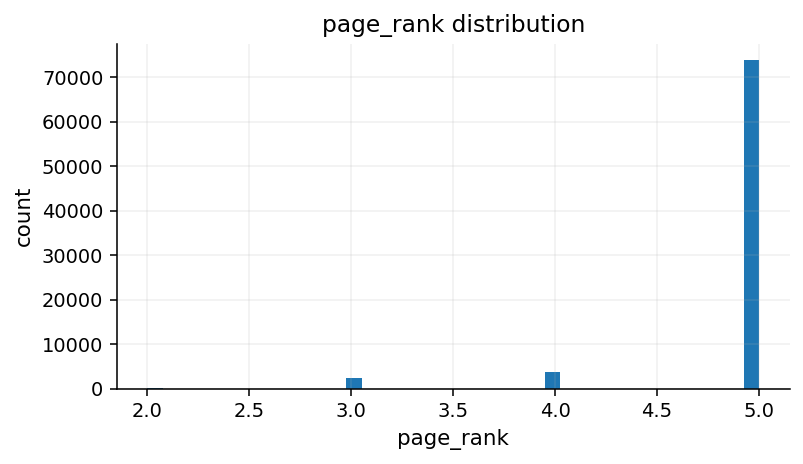

C:\Users\msist\AppData\Local\Temp\ipykernel_17164\333058349.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in labels_sorted], showfliers=False)


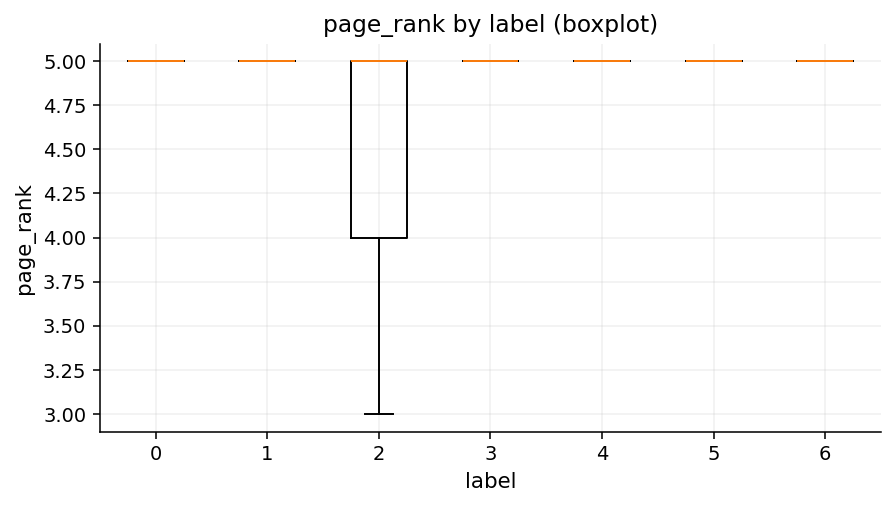

Effect size eta^2 (label explains page_rank): 0.28621772406346696


In [ ]:

# page_rank analysis (variance + per-label box)

if "page_rank" in df_dev.columns:
	pr = df_dev["page_rank"].astype(float)
	print("page_rank summary:")
	print(pr.describe())

	plt.figure(figsize=(6.2,3.2))
	plt.hist(pr.dropna(), bins=40)
	plt.title("page_rank distribution")
	plt.xlabel("page_rank")
	plt.ylabel("count")
	plt.show()

	# per-label boxplots (manual style)
	data = []
	labels_sorted = sorted(df_dev[label_col].unique())
	for lab in labels_sorted:
		data.append(df_dev.loc[df_dev[label_col]==lab, "page_rank"].astype(float).dropna().values)

	plt.figure(figsize=(7.2,3.6))
	plt.boxplot(data, labels=[str(l) for l in labels_sorted], showfliers=False)
	plt.title("page_rank by label (boxplot)")
	plt.xlabel("label")
	plt.ylabel("page_rank")
	plt.show()

	# quick ANOVA-like effect size (eta^2) without heavy stats
	overall_mean = pr.mean()
	ss_total = ((pr - overall_mean)**2).sum()
	ss_between = 0.0
	for lab in labels_sorted:
		v = df_dev.loc[df_dev[label_col]==lab, "page_rank"].astype(float)
		ss_between += len(v) * (v.mean() - overall_mean)**2
	eta2 = float(ss_between / ss_total) if ss_total > 0 else np.nan
	print("Effect size eta^2 (label explains page_rank):", eta2)
else:
	print("page_rank column not found.")


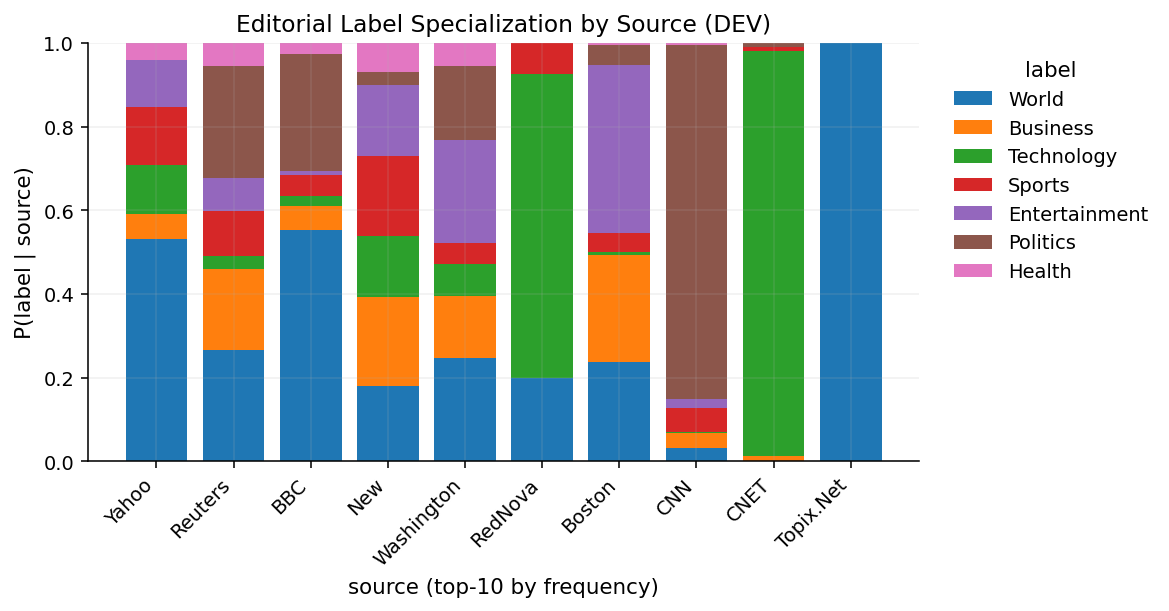

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Label name mapping
# =========================
label_names = {
	0: "World",
	1: "Business",
	2: "Technology",
	3: "Sports",
	4: "Entertainment",
	5: "Politics",
	6: "Health"
}


# Select top-10 sources by frequency

top_sources = (
	df_dev["source"]
	.value_counts()
	.head(10)
	.index
)

df_top = df_dev[df_dev["source"].isin(top_sources)]


# Compute P(label | source)

label_source_counts = (
	df_top
	.groupby(["source", "label"])
	.size()
	.unstack(fill_value=0)
)

label_source_probs = label_source_counts.div(
	label_source_counts.sum(axis=1),
	axis=0
)

# Sort sources by overall frequency (for nicer ordering)
label_source_probs = label_source_probs.loc[top_sources]


# Plot stacked bar chart
plt.figure(figsize=(8.5, 4.5))

bottom = np.zeros(len(label_source_probs))
x = np.arange(len(label_source_probs))

for label in sorted(label_source_probs.columns):
	plt.bar(
		x,
		label_source_probs[label].values,
		bottom=bottom,
		label=label_names[label]
	)
	bottom += label_source_probs[label].values

plt.xticks(
	x,
	label_source_probs.index,
	rotation=45,
	ha="right"
)

plt.ylabel("P(label | source)")
plt.xlabel("source (top-10 by frequency)")
plt.title("Editorial Label Specialization by Source (DEV)")
plt.legend(
	title="label",
	bbox_to_anchor=(1.02, 1),
	loc="upper left",
	frameon=False
)

plt.tight_layout()
plt.show()
